<a href="https://colab.research.google.com/github/jeffmcm1977/CMBAnalysis_SummerSchool/blob/master/CMB_School_Part_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical tools for image analysis

### Renée Hložek 

This notebook is based on tools used to analyse the Cosmic Microwave Background (CMB), which is the oldest observable light in the universe. 

## Code preliminaries
We use the following libraries in this code.  All are available through Anaconda.

In [106]:
import numpy as np
import matplotlib
import sys
import matplotlib.cm as cm
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import constants as cs # the constants module
import cmb_modules # the module of functions

### Generating maps from an input spectrum

One of the first things we need to do is to take an averaged spherical harmonic spectrum and make a map of the CMB. We start by reading in a precomputed spectrum.

Text(0.5, 0, '$\\ell$')

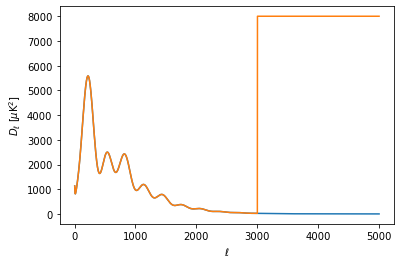

In [121]:
# read in the input CMB spectra
ell, DlTT = np.loadtxt("CAMB_fiducial_cosmo_scalCls.dat", usecols=(0, 1), unpack=True)
DlTT2 = np.copy(DlTT)
DlTT2[3000:] = 8000
plt.plot(ell,DlTT)
plt.plot(ell,DlTT2)
plt.ylabel(r'$D_{\ell}$ [$\mu$K$^2$]')
plt.xlabel(r'$\ell$')

This plot is the angular power spectrum of the CMB temperature anisotropies.  It is traditional to plot $D_\ell$ which give the variance on various angular scales.  This is related to the angular power spectrum $C_\ell$ by $D_\ell = \frac {\ell (\ell+1)} {2 \pi} C_\ell$.  The correct thing to use for creating CMB maps is $C_\ell$, but $D_\ell$ is what you are used to seeing plotted.

## Section 1.2: Temperature Anisotropy Map
In this step we generate a simulated map of the CMB sky with the spectrum we read in above.  Since the power spectrum is a function of $\ell$ we need to do much of the work in harmonic space.  If we were generating a map on the full sky we would need to work with spherical harmonics.  Here we consider a small patch of sky $(\sim 10^\circ \times 10^\circ)$ where we can use the "flat-sky" approximation and replace $\ell$ with $k = \sqrt{k_x^2 + k_y^2}$.  There is a linear dependence between these variables defined by $\ell = k* 2 \pi$.

In the flat sky approximation we generate a CMB map by:  (1) generating a 2D power spectrum by revolving the above spectrum (properly normalized) about the axis in polar coordinates, (2) generating a Gaussian random map with unit variance as our 'random realisation', (3) multiplying that maps from 1 and 2, and (4) Fourier transforming this to get a real space map.  We provide a function to do this and a function to plot this (and other maps) with a uniform color scale.

In [108]:
## variables to set up the size of the map
N = 2**10  # this is the number of pixels in a linear dimension
            ## since we are using lots of FFTs this should be a factor of 2^N
pix_size  = 0.5 # size of a pixel in arcminutes

## variables to set up the map plots
c_min = -400  # minimum for color bar
c_max = 400   # maximum for color bar
X_width = N*pix_size/60.  # horizontal map width in degrees
Y_width = N*pix_size/60.  # vertical map width in degrees

In [109]:
def make_CMB_T_map(N,pix_size,ell,DlTT):
    "makes a realization of a simulated CMB sky map given an input DlTT as a function of ell," 
    "the pixel size (pix_size) required and the number N of pixels in the linear dimension."
    #np.random.seed(100)
    # convert Dl to Cl
    ClTT = DlTT * 2 * np.pi / (ell*(ell+1.))
    ClTT[0] = 0. # set the monopole and the dipole of the Cl spectrum to zero
    ClTT[1] = 0.

    # make a 2D real space coordinate system
    inds = np.linspace(-0.5, 0.5, N) # create an array of size N between -0.5 and +0.5
    # construct grid of X and Y coordinates
    X, Y = np.meshgrid(inds, inds)
    # radial component R
    R = np.sqrt(X**2. + Y**2.)
    
    # now make a 2D CMB power spectrum
    pix_to_rad = (pix_size/60. * np.pi/180.) # going from pix_size in arcmins to degrees and then degrees to radians
    ell_scale_factor = 2. * np.pi /pix_to_rad  # now relating the angular size in radians to multipoles
    ell2d = R * ell_scale_factor # making a fourier space analogue to the real space R vector
    ClTT_expanded = np.zeros(int(ell2d.max())+1) 
    # making an expanded Cl spectrum (of zeros) that goes all the way to the size of the 2D ell vector
    ClTT_expanded[0:(ClTT.size)] = ClTT # fill in the Cls until the max of the ClTT vector

    # the 2D Cl spectrum is defined on the multiple vector set by the pixel scale
    CLTT2d = ClTT_expanded[ell2d.astype(int)] 

    # now make a realization of the CMB with the given power spectrum in real space
    random_array_for_T = np.random.normal(0,1,(N,N))
    FT_random_array_for_T = np.fft.fft2(random_array_for_T)   # take FFT since we are in Fourier space     
    FT_2d = np.sqrt(CLTT2d) * FT_random_array_for_T # we take the sqrt since the power spectrum is T^2

    # move back from ell space to real space
    CMB_T = np.fft.ifft2(np.fft.fftshift(FT_2d)) 
    # move back to pixel space for the map
    CMB_T /= pix_to_rad
    # we only want to plot the real component
    CMB_T = np.real(CMB_T)

    ## return the map
    return CMB_T
  ###############################

def Plot_CMB_Map(Map_to_Plot,c_min,c_max,X_width,Y_width):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    print("map mean:",np.mean(Map_to_Plot),"map rms:",np.std(Map_to_Plot))
    plt.gcf().set_size_inches(10, 10)
    im = plt.imshow(Map_to_Plot, interpolation='bilinear', origin='lower',cmap=cm.RdBu_r)
    im.set_clim(c_min,c_max)
    im.set_extent([0,X_width,0,Y_width])
    plt.ylabel(r"Angle $[^\circ]$")
    plt.xlabel(r"Angle $[^\circ]$")

    ax = plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax, label="Temperature [uK]")
  ###############################

Using the functions defined above, we now generate a map based on the power spectrum.

map mean: -11.799590813328132 map rms: 93.48216151243099


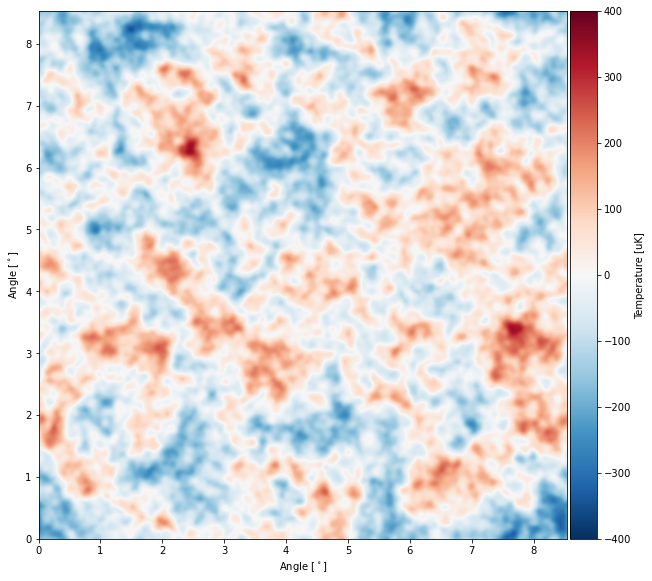

In [123]:
## make a CMB T map
ell, DlTT = np.loadtxt("CAMB_fiducial_cosmo_scalCls.dat", usecols=(0, 1), unpack=True)
CMB_T1 = make_CMB_T_map(N,pix_size,ell,DlTT)
Plot_CMB_Map(CMB_T1,c_min,c_max,X_width,Y_width)






map mean: -3.056418166684817 map rms: 97.72057785826709


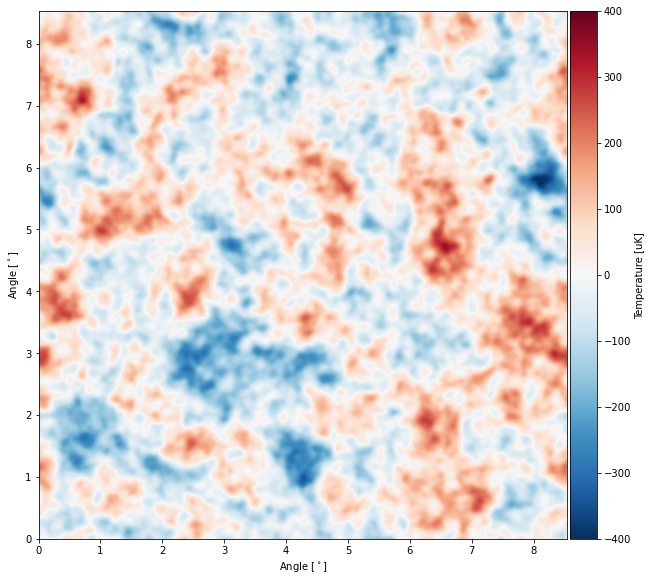

In [111]:
CMB_T2 = make_CMB_T_map(N,pix_size,ell,DlTT)
Plot_CMB_Map(CMB_T2,c_min,c_max,X_width,Y_width)


map mean: -13.151490321858347 map rms: 145.95412063596422


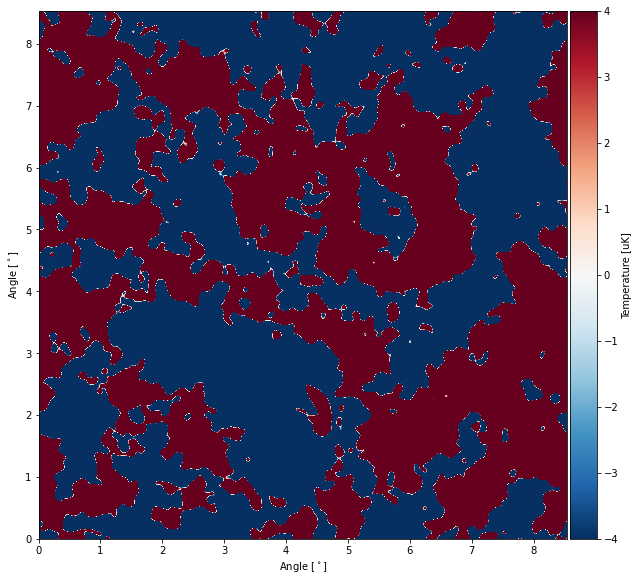

In [112]:
Plot_CMB_Map(CMB_T2-CMB_T1,c_min/100,c_max/100,X_width,Y_width)


This contour plot shows simulated CMB map we just generated.  If you generate it multiple times you will find that you get different patterns, however you will see that the typical size of the brightest and darkest spots will stay around $1^\circ$, corresponding to the peak of the angular power spectrum.  All simulated sky maps are displayed with the same color scale to permit visual comparison.

<font color='red'>EXERCISE: </font>    Run this multiple times to see how your realization changes at each iteration.

Discuss: (1)  how the CMB power sepctrum related to the realization, and (2) how the realization in harmonic space relates to the CMB map.

In [113]:
# your code and plots go here

We will now add some point sources to the map, so that we can estimate how those are affected by the instrument specifics

Number of sources required:  5000
map mean: -11.891026118718516 map rms: 30.644370848886826


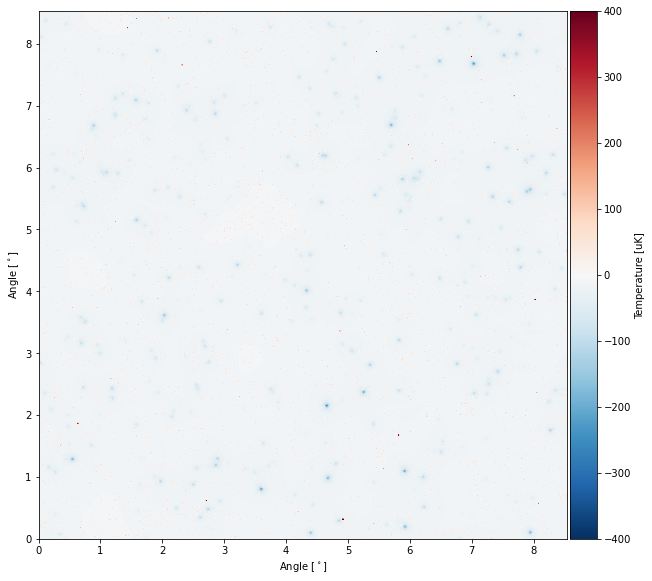

In [114]:
## make a point source map
Number_of_Sources  = cs.Number_of_Sources
Amplitude_of_Sources = cs.Amplitude_of_Sources*2
Number_of_Sources_EX = cs.Number_of_Sources_EX
Amplitude_of_Sources_EX = cs.Amplitude_of_Sources_EX
PSMap = cmb_modules.Poisson_source_component(N,pix_size,Number_of_Sources,Amplitude_of_Sources) 
PSMap +=  cmb_modules.Exponential_source_component(N,pix_size,Number_of_Sources_EX,Amplitude_of_Sources_EX)

Number_of_SZ_Clusters  = cs.Number_of_SZ_Clusters
Mean_Amplitude_of_SZ_Clusters = cs.Mean_Amplitude_of_SZ_Clusters
SZ_beta = cs.SZ_beta
SZ_Theta_core = cs.SZ_Theta_core

## make an SZ map
SZMap,SZCat = cmb_modules.SZ_source_component(N,pix_size,Number_of_SZ_Clusters,\
                                  Mean_Amplitude_of_SZ_Clusters,SZ_beta,SZ_Theta_core,False)

## add them all together to get the sky map at a single freuqency
total_map = CMB_T + PSMap + SZMap

Plot_CMB_Map(PSMap+SZMap,c_min,c_max,X_width,Y_width)

### Instrument Beam, Instrument Noise, and Filtering

The beam of a telescope determines the resolution we can see. We model this by generating a Gaussian beam pattern and convolve the map with it. We will now add noise to our original signal map and filter it so we can see how these instrument specifics change the map. 

map mean: -23.69061693204665 map rms: 93.43867204723371


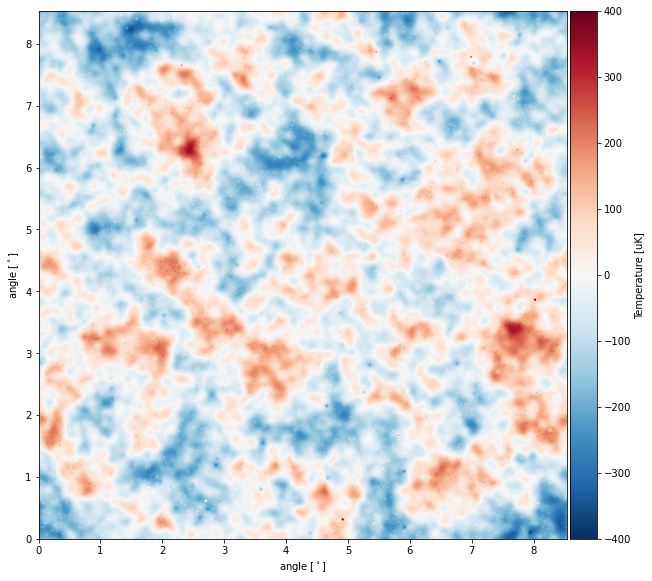

In [124]:
beam_size_fwhp = 1.25 # arcminutes

def convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,Map):
    "convolves a map with a Gaussian beam pattern.  NOTE: pix_size and beam_size_fwhp need to be in the same units" 
    # make a 2d gaussian 
    gaussian = make_2d_gaussian_beam(N,pix_size,beam_size_fwhp)
  
    # do the convolution
    FT_gaussian = np.fft.fft2(np.fft.fftshift(gaussian)) # first add the shift so that it is central
    FT_Map = np.fft.fft2(np.fft.fftshift(Map)) #shift the map too
    convolved_map = np.fft.fftshift(np.real(np.fft.ifft2(FT_gaussian*FT_Map))) 
    
    # return the convolved map
    return(convolved_map)
  ###############################   

def make_2d_gaussian_beam(N,pix_size,beam_size_fwhp):
     # make a 2d coordinate system
    N=int(N)
    ones = np.ones(N)
    inds  = (np.arange(N)+.5 - N/2.) * pix_size
    X = np.outer(ones,inds)
    Y = np.transpose(X)
    R = np.sqrt(X**2. + Y**2.)
    # plt.title('Radial coordinates')
    # plt.imshow(R)
    # plt.colorbar()
    # plt.show()
  
    # make a 2d gaussian 
    beam_sigma = beam_size_fwhp / np.sqrt(8.*np.log(2))
    gaussian = np.exp(-.5 *(R/beam_sigma)**2.)
    gaussian = gaussian / np.sum(gaussian)
    # return the gaussian
    # plt.title('Gaussian beam')
    # plt.imshow(gaussian)
    # plt.colorbar()
    # plt.show()
    return(gaussian)
  ###############################  
    
    
## convolve the signal part of the map

CMB_T_convolved = convolve_map_with_gaussian_beam(N,pix_size,beam_size_fwhp,CMB_T1+PSMap+SZMap)

p=cmb_modules.Plot_CMB_Map(CMB_T_convolved,c_min,c_max,X_width,Y_width)

If instead we have a map with five times the beam size, we would have a corresponding map determined by the following: 


map mean: -23.69061693204665 map rms: 93.43867204723371


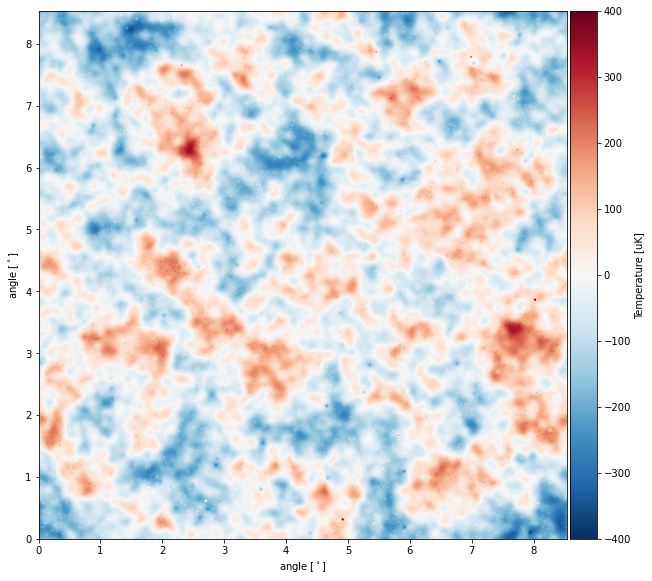

map mean: -34.055343304461076 map rms: 83.86927291727673


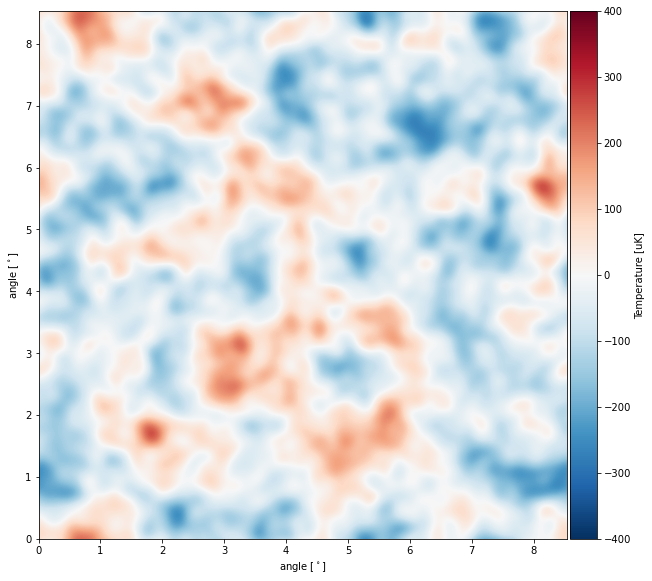

In [126]:
CMB_T_convolved5x = convolve_map_with_gaussian_beam(N,pix_size,10*beam_size_fwhp,CMB_T+PSMap+SZMap)

p=cmb_modules.Plot_CMB_Map(CMB_T_convolved,c_min,c_max,X_width,Y_width)
p5x=cmb_modules.Plot_CMB_Map(CMB_T_convolved5x,c_min,c_max,X_width,Y_width)

<font color='red'>EXERCISE: </font> What happens to the points sources when you change the beam of your experiment? There are three typical beam sizes for CMB experiments: 1) large angular scale B-mode observatories which have ~30 arcminute beams; 2) medium scale observatories such as the Planck satellite that has a ~3 arcminute beam, and 3) high resolution observatories such as ACT and SPT that have ~1 arcminute beams. Convolve your map with each of these cases and compare the differences.

## Noise Map

Ground based CMB instruments suffer from several types of noise.  This includes: (1) White noise drawn from a gaussian distribution; (2) atmospheric noise which grows larger on large angular scales, this can be understood in terms of Kolmogorov turbulence; and (3) $1/f$ noise in the detectors.  Both atmospheric and detector $1/f$ manifest as correlated noise in map space.  However, like the CMB these noise components are very nearly uncorrelated in Fourier space.  We will build these noise terms in Fourier space and display them in map space. 

We choose a white noise level of 10 $\mu\mathrm{K}$-arcmin to approximate the current deep maps coming from ACTPol and SPTPol.  The $1/f$ noise is similar to what would be seen in an experiment at the south pole.  When turned on, this noise leads to the effect of "striping" in the maps.  In later notebooks, we default to turning the atmospheric and 1/f noise components off since if they are included we may want to filter the maps before estimating the power spectrum.  (This is easy, but is not yet implemented).  The atmospheric noise (Kolmogorov turbulence) has a 2D spectrum similar to CMB leading to similar patterns in the maps.

map mean: -18.588488276938936 map rms: 68.19715956423401


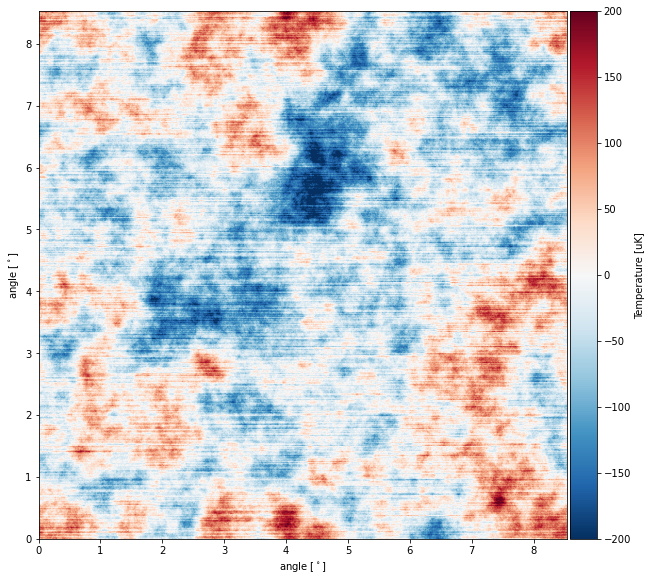

In [117]:
white_noise_level = 10.
atmospheric_noise_level = 0.5  # multiply by zero to turn this off
one_over_f_noise_level = 0.2 # multiply by zero to turn this off

def make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level):
    "makes a realization of instrument noise, atmosphere and 1/f noise level set at 1 degrees"
    ## make a white noise map
    white_noise = np.random.normal(0,1,(N,N)) * white_noise_level/pix_size
 
    ## make an atnosperhic noise map
    atmospheric_noise = 0.
    if (atmospheric_noise_level != 0):
        ones = np.ones(N)
        inds  = (np.arange(N)+.5 - N/2.) 
        X = np.outer(ones,inds)
        Y = np.transpose(X)
        R = np.sqrt(X**2. + Y**2.) * pix_size /60. ## angles relative to 1 degrees  
        mag_k = 2 * np.pi/(R+.01)  ## 0.01 is a regularization factor
        atmospheric_noise = np.fft.fft2(np.random.normal(0,1,(N,N)))
        atmospheric_noise  = np.fft.ifft2(atmospheric_noise * np.fft.fftshift(mag_k**(5/3.)))
        atmospheric_noise = atmospheric_noise * atmospheric_noise_level/pix_size

    ## make a 1/f map, along a single direction to illustrate striping 
    oneoverf_noise = 0.
    if (one_over_f_noise_level != 0): 
        ones = np.ones(N)
        inds  = (np.arange(N)+.5 - N/2.) 
        X = np.outer(ones,inds) * pix_size /60. ## angles relative to 1 degrees 
        kx = 2 * np.pi/(X+.01) ## 0.01 is a regularization factor
        oneoverf_noise = np.fft.fft2(np.random.normal(0,1,(N,N)))
        oneoverf_noise = np.fft.ifft2(oneoverf_noise * np.fft.fftshift(kx))
        oneoverf_noise = oneoverf_noise * one_over_f_noise_level/pix_size

    ## return the noise map
    noise_map = np.real(white_noise + atmospheric_noise + oneoverf_noise)
    return(noise_map)
  ###############################

## make an instrument noise map
Noise = make_noise_map(N,pix_size,white_noise_level,atmospheric_noise_level,one_over_f_noise_level)

p=cmb_modules.Plot_CMB_Map(Noise,c_min/2.,c_max/2.,X_width,Y_width)

<font color='red'>EXERCISE: </font> This plot shows a realization of instrumental noise related to the sampling rate of the instrument (this is known as detector $1/f$ noise) + atmospheric noise.  The atmospheric noise looks similar to the CMB since it has a similar 2d spectrum. To understand these components individually, turn each off and make plots of each component separately. Comment on how these look.  

## Filtering

In maps with frequency dependent noise it is often advantageous to filter the maps to 'whiten' the noise spectrum.   There are a wide variety of choices of what to do here.  For both atmospheric and $1/f$ noise, a high pass filter would be an effective choice.  This could either be a square filter (where the modes below some cutoff are set to zero while shorter wavelength modes are kept unchanged) or a filter that weights the fourier modes by $1/A$ where $A$ is the amplitude of the noise distribution. Below is code that masks out $N_{mask}$ Fourier modes along the scan direction. 

map mean: 9.71445146547012e-17 map rms: 37.66188441674776


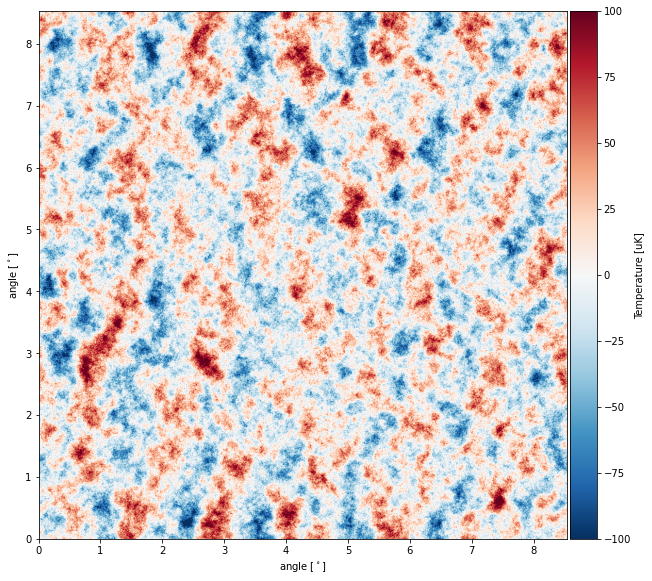

In [118]:
N_mask =4

def Filter_Map(Map,N,N_mask):
    ## set up a x, y, and r coordinates for mask generation
    ones = np.ones(N) # N is the size of the map
    inds  = (np.arange(N)+.5 - N/2.) 

    X = np.outer(ones,inds)
    Y = np.transpose(X)
    R = np.sqrt(X**2. + Y**2.)  ## angles realative to 1 degrees  
    
    ## make a mask
    mask  = np.ones([N,N])
    mask[np.where(np.abs(X) < N_mask)]  = 0
    
    ## apply the filter in fourier space
    FMap = np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(Map)))
    FMap_filtered = FMap * mask
    Map_filtered = np.real(np.fft.fftshift(np.fft.fft2(np.fft.fftshift(FMap_filtered))))
    
    ## return the output
    return(Map_filtered)


filtered = Filter_Map(Noise,N,N_mask)
p=cmb_modules.Plot_CMB_Map(filtered,c_min/4.,c_max/4.,X_width,Y_width)

<font color='red'>EXERCISE: </font>  Find the minimum $N_{mask}$ that effectively whitens the noise spectrum with the bad $1/f$ turned on.  See how this filter works for atmospheric noise.  Comment on whether this filter works and whether it is a good choice for atmospheric noise.

## Calcium images instead of CMB ones

We will now apply the same technique but to this image from https://s3.valeria.science/flclab-calcium/index.html#datasets

map mean: 1200.0196571350098 map rms: 716.1298930065927


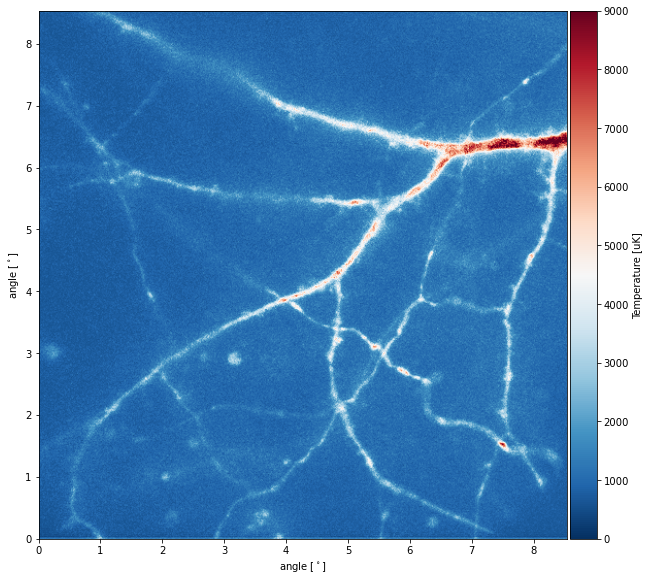

map mean: 1200.0196571350098 map rms: 672.4957008097322


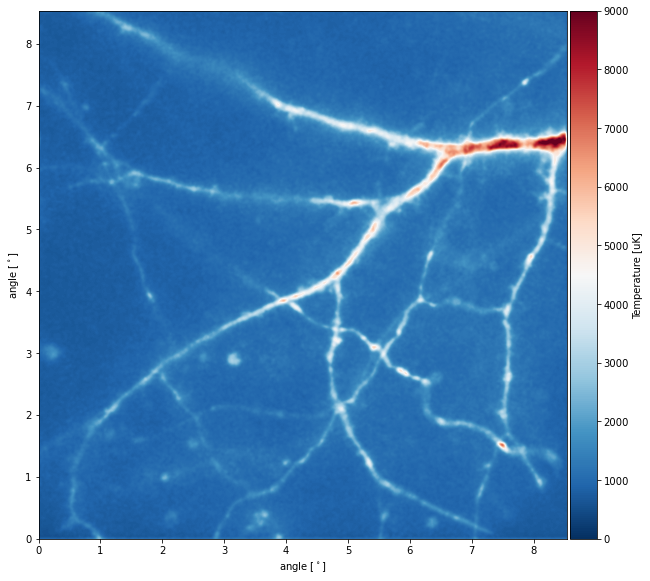

map mean: 1200.0196571350098 map rms: 542.8331627191949


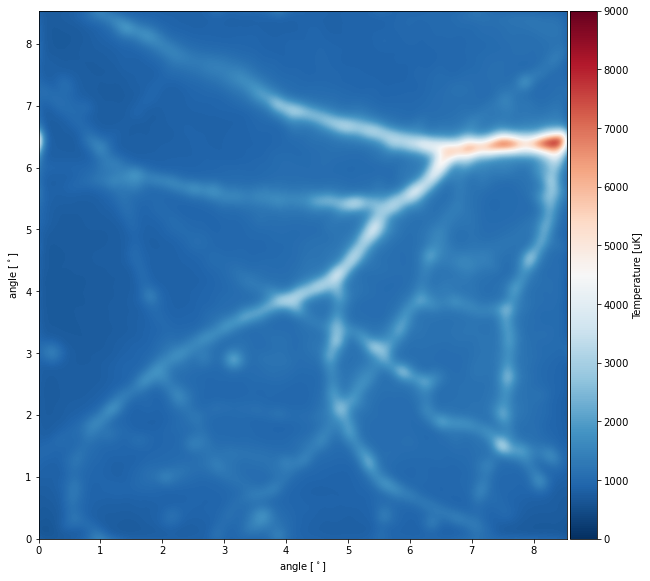

In [127]:
import h5py
filename = "calcium/19-2.tif"

import matplotlib.pyplot as plt
I = plt.imread(filename)
# plt.imshow(I)
# plt.colorbar()
# plt.show()

Ncalc = 512
X_widthcalc=512/60.
Y_widthcalc = 512/60.
c_maxcalc = 9000
c_mincalc = 0

p=cmb_modules.Plot_CMB_Map(I,c_mincalc,c_maxcalc,X_widthcalc,Y_widthcalc)

calcium_convolved = convolve_map_with_gaussian_beam(Ncalc,pix_size,beam_size_fwhp,I)
calcium_convolved5x = convolve_map_with_gaussian_beam(Ncalc,pix_size,5*beam_size_fwhp,I)

p=cmb_modules.Plot_CMB_Map(calcium_convolved,c_mincalc,c_maxcalc,X_widthcalc,Y_widthcalc)
p=cmb_modules.Plot_CMB_Map(calcium_convolved5x,c_mincalc,c_maxcalc,X_widthcalc,Y_widthcalc)